In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od

od.download("https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  Papillio


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data


100%|██████████████████████████████████████████████████████████████████| 1.78G/1.78G [05:15<00:00, 6.07MB/s]


In [ ]:
files = [r"datasets\nyc-yellow-taxi-trip-data\yellow_tripdata_2015-01.csv",
         r"datasets\nyc-yellow-taxi-trip-data\yellow_tripdata_2016-01.csv",
         r"datasets\nyc-yellow-taxi-trip-data\yellow_tripdata_2016-02.csv",
         r"datasets\nyc-yellow-taxi-trip-data\yellow_tripdata_2016-03.csv"]

df_list = []

for file in files:
    df_list.append(pd.read_csv(file))

df = pd.concat(df_list)

In [9]:
print(df.head())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2015-01-15 19:05:39   2015-01-15 19:23:42                1   
1         1  2015-01-10 20:33:38   2015-01-10 20:53:28                1   
2         1  2015-01-10 20:33:38   2015-01-10 20:43:41                1   
3         1  2015-01-10 20:33:39   2015-01-10 20:35:31                1   
4         1  2015-01-10 20:33:39   2015-01-10 20:52:58                1   

   trip_distance  pickup_longitude  pickup_latitude  RateCodeID  \
0           1.59        -73.993896        40.750111         1.0   
1           3.30        -74.001648        40.724243         1.0   
2           1.80        -73.963341        40.802788         1.0   
3           0.50        -74.009087        40.713818         1.0   
4           3.00        -73.971176        40.762428         1.0   

  store_and_fwd_flag  dropoff_longitude  dropoff_latitude  payment_type  \
0                  N         -73.974785         40.750618             1

In [15]:
df["RateCodeID"] = df["RateCodeID"].fillna(df["RatecodeID"])
df = df.drop(columns="RatecodeID")
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1.0,N,-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.30,-74.001648,40.724243,1.0,N,-73.994415,40.759109,1,14.5,0.5,0.5,2.00,0.0,0.3,17.80
2,1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.80,-73.963341,40.802788,1.0,N,-73.951820,40.824413,2,9.5,0.5,0.5,0.00,0.0,0.3,10.80
3,1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.50,-74.009087,40.713818,1.0,N,-74.004326,40.719986,2,3.5,0.5,0.5,0.00,0.0,0.3,4.80
4,1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.00,-73.971176,40.762428,1.0,N,-74.004181,40.742653,2,15.0,0.5,0.5,0.00,0.0,0.3,16.30


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 47248845 entries, 0 to 12210951
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             float64
 8   store_and_fwd_flag     str    
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(13), int64(3), str(3)
memory usage: 7.0 GB


In [25]:
# Question 1: Does passenger count and payment type affect fare amount?
# Load only needed columns
cols = ["passenger_count", "fare_amount", "payment_type"]
copy = df[cols]
# Subset only the ones greater than 0 to remove the refunded trips
copy = copy[copy["fare_amount"] > 0]
agg = copy.groupby(["passenger_count", "payment_type"])["fare_amount"].mean().reset_index()
agg.head()

,passenger_count,payment_type,fare_amount
0,0,1,16.522104
1,0,2,10.962033
2,0,3,10.315696
3,0,4,5.788919
4,1,1,12.799953


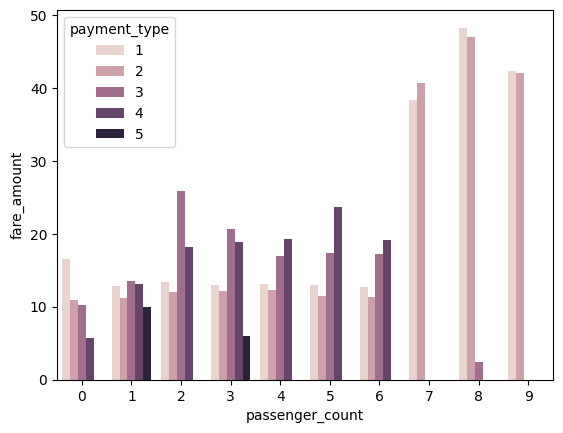

In [26]:
sns.barplot(data=agg, x="passenger_count", y="fare_amount", hue="payment_type")
plt.show()

In [58]:
# Question 2: Which hours is it most common to get refunded trips?
refunded_df = df[["fare_amount", "tpep_pickup_datetime"]]
refunded_df["refunded"] = df["fare_amount"] <= 0
refunded_df["tpep_pickup_datetime"] = pd.to_datetime(refunded_df["tpep_pickup_datetime"])
refunded_df["hour_pickup"] = refunded_df["tpep_pickup_datetime"].dt.hour
agg = refunded_df.groupby(["refunded", "hour_pickup"]).size().reset_index(name="refunded_count")
agg = agg[agg["refunded"]]

totals = refunded_df.groupby("hour_pickup").size().reset_index(name="total_count")
agg = agg.merge(totals, on="hour_pickup")
agg["refunded_ratio"] =  agg["refunded_count"]/agg["total_count"] 
agg["non-refunded_ratio"] = 1 - agg["refunded_ratio"]
refunded_agg = agg[agg["refunded"]]
refunded_agg.sort_values(by="refunded_ratio", ascending=False).head()

,refunded,hour_pickup,refunded_count,total_count,refunded_ratio,non-refunded_ratio
4,True,4,892,513887,0.001736,0.998264
5,True,5,769,477293,0.001611,0.998389
3,True,3,1025,689141,0.001487,0.998513
2,True,2,1157,918449,0.001260,0.998740
1,True,1,1391,1246344,0.001116,0.998884


0     0.000925
1     0.001116
2     0.001260
3     0.001487
4     0.001736
5     0.001611
6     0.000879
7     0.000575
8     0.000499
9     0.000527
10    0.000541
11    0.000532
12    0.000499
13    0.000582
14    0.000614
15    0.000663
16    0.000697
17    0.000572
18    0.000516
19    0.000510
20    0.000531
21    0.000564
22    0.000619
23    0.000754
Name: refunded_ratio, dtype: float64


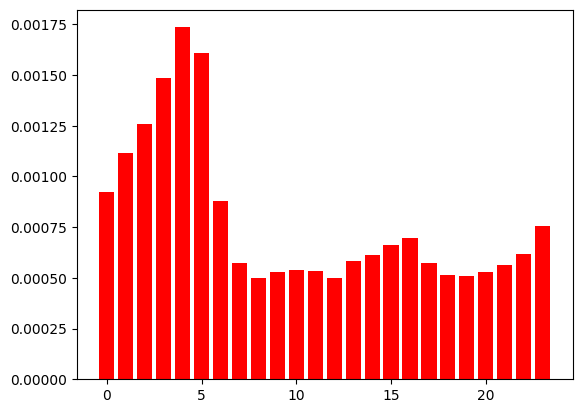

In [59]:
print(agg["refunded_ratio"])
plt.bar(agg["hour_pickup"], agg["refunded_ratio"], color='r')
plt.show()

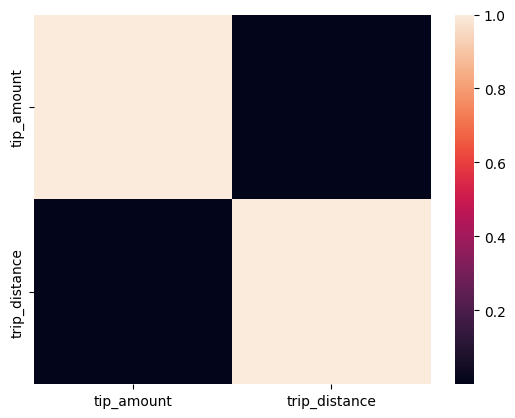

In [67]:
# Question 3: Is there a correlation between tips and distance?
sns.heatmap(df[["tip_amount", "trip_distance"]].corr())
plt.show()